# Batched photonic-lantern propagation with a DM-driven input PSF

Loads a DM influence function via `specula`, uses it to generate a *batch*
of aberrated input pupil fields, and propagates the whole batch through a
characterized photonic-lantern `ChainPropagator` in a single call -- then
reconstructs the output fields, visualizes them, and extracts per-core
output signals aligned to the lantern's ideal hex-grid layout.

`specula` is the only non-`cbeam` dependency here, and it is used only in
this notebook (`batch_pipeline` itself has no specula dependency anywhere --
see the import cell below). For a specula-free, pure numpy-vs-JAX /
batched-vs-one-at-a-time efficiency comparison, see `Batched.ipynb`.

In [1]:
import os
os.environ["CBEAM_BACKEND"] = "jax"

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


## Import the batch pipeline

In [2]:
# batch_pipeline is the maintained package; batch_propagation_pipeline.py
# (a single top-level module) is kept only as a backward-compatibility shim
# re-exporting the same names for older scripts/notebooks -- new code should
# import batch_pipeline directly.
from batch_pipeline import *
from cbeam.waveguide import hex_ring_positions

# Ideal (unit-pitch) hex-grid layout of the lantern's output ports, pulled
# from the library instead of hand-typed: get_simulation_parameters() builds
# the *actual* port layout via
# output_positions = hex_ring_positions(nrings, rclad / 2.5) (see
# batch_pipeline/config.py) -- same function, just physical microns instead
# of unit pitch.
#
# Ordering matters here: map_evaluated_to_ideal_geometry() pairs row k of
# this list with row k of the *detected* core centres for its initial
# Procrustes alignment, and analysis._peak_centroids (which produces those
# detected centres) always sorts them by (round(y,2), round(x,2)) -- see its
# own docstring. So this list has to be sorted the same way, or that initial
# pairing is meaningless and the Hungarian re-matching right after it can
# lock onto the wrong (but still hexagonally-plausible) rotation of the grid.
# hex_ring_positions() itself returns ring-then-angle order, NOT this sort --
# passing its raw output through empirically raises the residual matching
# RMS error in map_evaluated_to_ideal_geometry() by ~30x (checked against
# this notebook's own detected centres), so re-sort it explicitly.
ideal_grid_positions = sorted(
    hex_ring_positions(N_RINGS, 1.0),
    key=lambda pt: (round(pt[1], 2), round(pt[0], 2)),
)
assert len(ideal_grid_positions) == N_SIGNALS, (
    f"hex_ring_positions(N_RINGS, 1.0) returned {len(ideal_grid_positions)} "
    f"positions but the pipeline expects N_SIGNALS={N_SIGNALS} output ports."
)

print(f"Batch pipeline imported successfully ({len(ideal_grid_positions)} output ports)")


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Using JAX backend.
Using diffrax for ODE integration.
Batch pipeline imported successfully (19 output ports)


## Optional: profiling helper

A small utility that manually replays the setup steps
`BatchPropagationPipeline.__init__` performs for one wavelength, timing each
one individually. It does **not** build a real pipeline -- it's read-only
profiling against an already-built `prop12`, used a couple of cells further
down.

In [3]:
import time
import numpy as np

from batch_pipeline import (
    get_waveguide_properties,
    IncidentFieldGenerator,
    ModalProjector,
    BatchPropagationPipeline,
    DEFAULT_GRID_RESOLUTION,
)


def profile_pipeline_preset(prop12, p, ifunc, grid_resolution=DEFAULT_GRID_RESOLUTION):
    """
    Manually replays BatchPropagationPipeline.__init__'s steps for one
    wavelength, timing each one. Does NOT construct a real pipeline --
    this is read-only profiling against an already-built prop12.
    """
    timings = {}

    t0 = time.perf_counter()
    wvg_props_input = get_waveguide_properties(prop12, mesh_z=0)
    t1 = time.perf_counter()
    timings["get_waveguide_properties(input, mesh_z=0)"] = t1 - t0

    wvg_props_output = get_waveguide_properties(prop12, mesh_z=p["z_ex"])
    t2 = time.perf_counter()
    timings["get_waveguide_properties(output, mesh_z=z_ex)"] = t2 - t1

    field_gen = IncidentFieldGenerator(p, ifunc, xp=np)
    t3 = time.perf_counter()
    timings["IncidentFieldGenerator.__init__ (mask + ifunc_matrix)"] = t3 - t2

    field_gen.precompute_interpolation_weights(wvg_props_input["points"])
    t4 = time.perf_counter()
    timings["precompute_interpolation_weights"] = t4 - t3

    modal_proj = ModalProjector(wvg_props_input, xp=np)
    t5 = time.perf_counter()
    timings["ModalProjector.__init__"] = t5 - t4

    # Replicates _precompute_delaunay_grid without needing a fully
    # constructed BatchPropagationPipeline instance.
    dummy = BatchPropagationPipeline.__new__(BatchPropagationPipeline)
    dummy.wvg_props_output = wvg_props_output
    _ = dummy._precompute_delaunay_grid(grid_resolution)
    t6 = time.perf_counter()
    timings[f"_precompute_delaunay_grid(resolution={grid_resolution})"] = t6 - t5

    print("\n" + "=" * 60)
    print("PRESET-PHASE TIMING BREAKDOWN")
    print("=" * 60)
    total = t6 - t0
    for label, dt in timings.items():
        bar = "#" * max(1, int(40 * dt / max(total, 1e-9)))
        print(f"{dt:7.3f} s  {bar:<40s}  {label}")
    print("-" * 60)
    print(f"{total:7.3f} s  TOTAL")
    print("=" * 60)

    return timings


## Simulation parameters

In [4]:
p = get_simulation_parameters(3, 0.8)

print("\n" + "="*60)
print("SIMULATION PARAMETERS")
print("="*60)
print(f"Wavelength: {p['wl']} μm")
print(f"Lantern length: {p['z_ex']} μm")
print(f"Cladding radius: {p['rclad']} μm")
print(f"Jacket radius: {p['rjack']} μm")
print(f"Core radius: {p['rcore']:.3f} μm")
print(f"Taper factor: {p['taper_factor']}")
print(f"Available influence function: {p['ifunc_file']}")



SIMULATION PARAMETERS
Wavelength: 0.8 μm
Lantern length: 100000 μm
Cladding radius: 9.0 μm
Jacket radius: 27 μm
Core radius: 0.150 μm
Taper factor: 12.0
Available influence function: /raid2/gcarla/git/ANDES/andes/PASSATA_scripts/data/ifunc/ANDES_400pix_all_modes.fits


## Load the influence function and build the propagator

This is the only place in the whole notebook -- and in the whole
`batch_pipeline` package -- that depends on `specula`: the DM
influence-function FITS file is loaded via
`specula.data_objects.ifunc.IFunc`. Everything downstream only touches the
resulting `ifunc` object's `.mask_inf_func` / `.influence_function`
attributes, so `batch_pipeline` itself never imports specula --
`build_and_characterize_lantern()` and `BatchPropagationPipeline` both just
take `ifunc` as a plain argument (see `batch_pipeline/run.py`, which takes
the same approach for `main_batch_propagation`).

In [5]:
import specula

print("Initializing SPECULA GPU...")
specula.init(0)
from specula.data_objects.ifunc import IFunc

print("Loading influence function...")
print(p["ifunc_file"])
ifunc = IFunc.restore(p["ifunc_file"])
mask = ifunc.mask_inf_func.get()

# Re-center the mask: diagnose_input_psf() below flags an off-center mask as
# a PSF-alignment problem, so fix it up front rather than fighting it later.
y_cent = np.mean(np.where(mask > 0)[0])
x_cent = np.mean(np.where(mask > 0)[1])
center_y = mask.shape[0] // 2
center_x = mask.shape[1] // 2
shift_y = int(center_y - y_cent)
shift_x = int(center_x - x_cent)
print('shift_x, shift_y', shift_x, shift_y)

mask_centered = np.roll(mask, shift_y, axis=0)
mask_centered = np.roll(mask_centered, shift_x, axis=1)
ifunc.mask_inf_func.set(mask_centered)

print(f"  Influence function modes: {len(ifunc.influence_function)}")

print("\nBuilding photonic lantern propagator...")
# reuse_cache=True: load a previously saved characterization for this
# (port-count, wavelength) instead of recomputing it (minutes -> seconds).
# The cache tag does NOT encode taper_factor / resolutions / radii (see
# build_and_characterize_lantern's docstring) -- if you change those, delete
# the matching files under ./data/ or pass reuse_cache=False to force a
# fresh characterization.
prop12 = build_and_characterize_lantern(p, reuse_cache=True)

print(f"  Propagator type: {type(prop12).__name__}")
print(f"  Total z range: {prop12.zs[0]:.0f} to {prop12.zs[-1]:.0f} μm")


2026-09-15 16:42:18,485 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.1.1
2026-09-15 16:42:18,490 [INFO]: [specula]: Default device is GPU number 0


Initializing SPECULA GPU...
Loading influence function...
/raid2/gcarla/git/ANDES/andes/PASSATA_scripts/data/ifunc/ANDES_400pix_all_modes.fits
shift_x, shift_y 0 0
  Influence function modes: 10

Building photonic lantern propagator...

  loaded cached characterization '19port_0800_front'

  loaded cached characterization '19port_0800_back'
  Propagator type: ChainPropagator
  Total z range: 0 to 100000 μm


## Build the batch propagation pipeline

Creating batch propagation pipeline...

[Interpolation Setup]
  Padded grid size: 1600
  Grid parity: even
  Center offset: 800.0
  Pixel scale: 0.5532786885245902 μm/pixel
  Mesh X range: [-27.000, 27.000] μm
  Mesh Y range: [-26.852, 26.852] μm
  Valid interpolation points: 12495 / 12495

=== RUNNING INPUT PSF CENTERING & SCALE DIAGNOSTIC ===

[MASK CENTERING CHECK]
  Mask shape: (400, 400)
  Mask centroid: (199.49, 199.81)
  Expected center: (199.50, 199.50)
  Offset: (-0.013, 0.308) pixels
  ⚠️  WARNING: Mask is off-center! This will cause PSF misalignment.
  Recommendation: Re-center the mask before loading or adjust in IFunc object.

[FFT GRID CHECK]
  FFT grid shape: (1600, 1600)
  FFT center index: (800, 800)
  PSF peak index: (np.int64(800), np.int64(800))
  Centering offset: (np.int64(0), np.int64(0)) pixels
  PSF centroid (subpixel): (799.999, 799.997)
  Centroid offset: (-0.001, -0.003) pixels

[MESH INTERPOLATION CHECK]
  Mesh PSF peak: (0.068, 0.067) μm
  Nearest core (#1

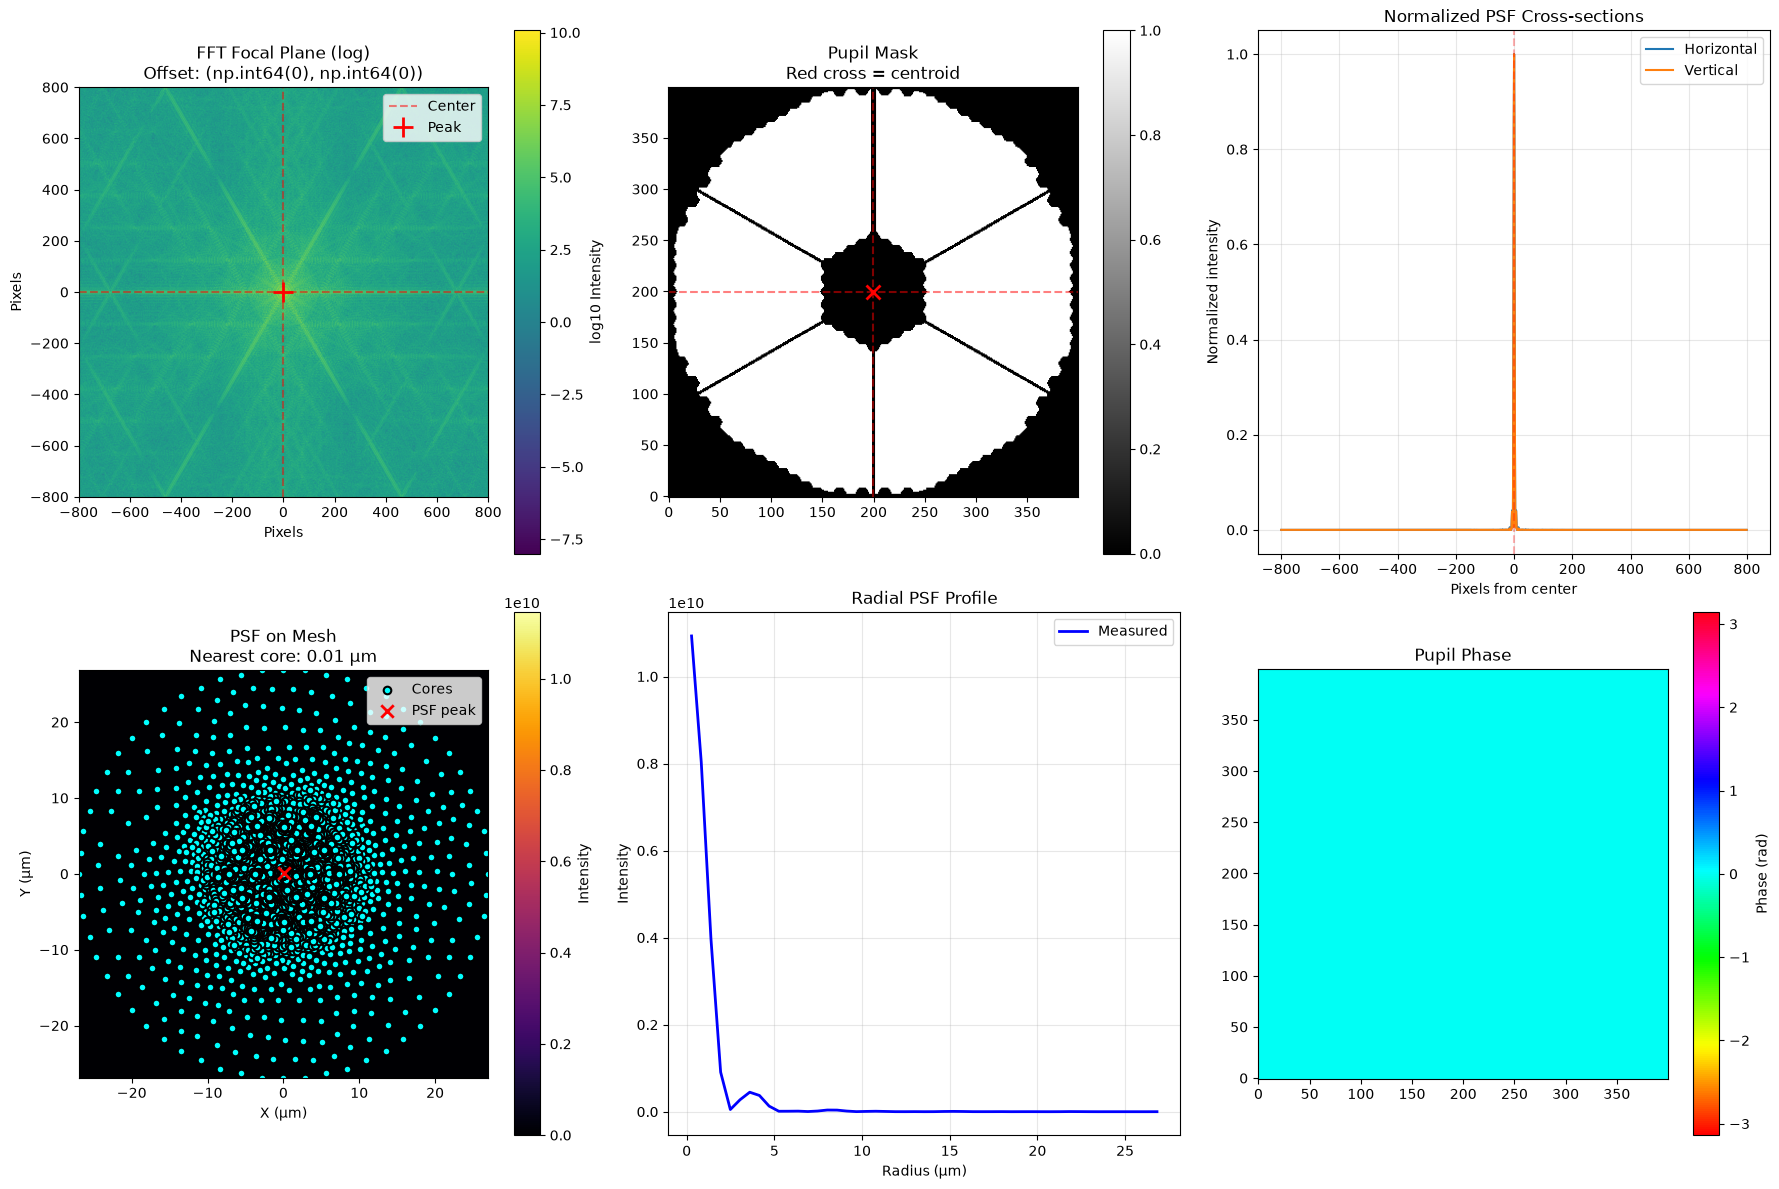


DIAGNOSTIC SUMMARY
Issues found:
  ⚠️  Mask is off-center

Recommendations:
  1. Check mask centering in IFunc
  2. Verify pixel_scale_um matches FFT grid spacing
  3. Check mesh interpolation coordinate mapping
Waveguide Properties:
  Input modes: 20
  Output modes: 20
  Mesh points at input: 12495
  Mesh points at output: 12495


In [6]:
print("Creating batch propagation pipeline...\n")
pipeline = BatchPropagationPipeline(prop12, p, ifunc)

diagnose_input_psf(pipeline)

print("Waveguide Properties:")
print(f"  Input modes: {pipeline.wvg_props_input['n_modes']}")
print(f"  Output modes: {pipeline.wvg_props_output['n_modes']}")
print(f"  Mesh points at input: {pipeline.wvg_props_input['points'].shape[0]}")
print(f"  Mesh points at output: {pipeline.wvg_props_output['points'].shape[0]}")


## Optional: profile pipeline construction cost

In [7]:
profile_pipeline_preset(prop12, p, ifunc)


[Interpolation Setup]
  Padded grid size: 1600
  Grid parity: even
  Center offset: 800.0
  Pixel scale: 0.5532786885245902 μm/pixel
  Mesh X range: [-27.000, 27.000] μm
  Mesh Y range: [-26.852, 26.852] μm
  Valid interpolation points: 12495 / 12495

PRESET-PHASE TIMING BREAKDOWN
  0.015 s  #                                         get_waveguide_properties(input, mesh_z=0)
  0.014 s  #                                         get_waveguide_properties(output, mesh_z=z_ex)
  0.009 s  #                                         IncidentFieldGenerator.__init__ (mask + ifunc_matrix)
  0.001 s  #                                         precompute_interpolation_weights
  0.003 s  #                                         ModalProjector.__init__
  4.832 s  #######################################   _precompute_delaunay_grid(resolution=400)
------------------------------------------------------------
  4.874 s  TOTAL


{'get_waveguide_properties(input, mesh_z=0)': 0.015318279154598713,
 'get_waveguide_properties(output, mesh_z=z_ex)': 0.013996987603604794,
 'IncidentFieldGenerator.__init__ (mask + ifunc_matrix)': 0.008609295822679996,
 'precompute_interpolation_weights': 0.0011185165494680405,
 'ModalProjector.__init__': 0.002662021666765213,
 '_precompute_delaunay_grid(resolution=400)': 4.8318863762542605}

## Generate aberration configurations

In [8]:
coeff0, _labels0 = create_random_aberration_configs(n=100, m=9, minv=-400, maxv=400)
coeff1, labels1 = create_ramp_aberration_configs([0], 20, 0, 400)


In [9]:
print("\nGenerating batch of input modal coefficients...\n")
print(coeff0.shape)
start_time = time.time()
u0_batch = pipeline.generate_batch_modal_coefficients(coeff0, use_gpu=False)
elapsed = time.time() - start_time
print(f"\ngenerate_batch_modal_coefficients Complete:")
print(f"  Elapsed time: {elapsed:.1f} seconds")
print(f"Input Modal Coefficient Batch:")
print(f"  Shape: {u0_batch.shape}")
print(f"  Dtype: {u0_batch.dtype}")
print(f"  Memory: {u0_batch.nbytes / 1e6:.1f} MB")

u1_batch = pipeline.generate_batch_modal_coefficients(coeff1, use_gpu=False)



Generating batch of input modal coefficients...

(100, 9)
  Generating modal coefficients for 100 fields (chunk_size=64, device=CPU) ...
    field-gen chunk 0–63 done.
    field-gen chunk 64–99 done.
  Field generation complete.

generate_batch_modal_coefficients Complete:
  Elapsed time: 3.4 seconds
Input Modal Coefficient Batch:
  Shape: (100, 20)
  Dtype: complex128
  Memory: 0.0 MB


## Propagate the batch through the lantern

In [10]:
print("\nPropagating batch through lantern...")
start_time = time.time()

uf_batch0, zs0, us_batch0 = pipeline.propagate_batch(u0_batch)
uf_batch1, zs1, us_batch1 = pipeline.propagate_batch(u1_batch)

elapsed = time.time() - start_time
print(f"\nPropagation Complete:")
print(f"  Elapsed time: {elapsed:.1f} seconds")
print(f"  Output modal coefficients shape: {uf_batch0.shape}")
print(f"  Propagation z-points: {len(zs0)}")



Propagating batch through lantern...
  Propagating 100 fields (chunk_size=10000) ...
    propagation chunk 0–99 done.
  Batch propagation complete.
  Propagating 20 fields (chunk_size=10000) ...
    propagation chunk 0–19 done.
  Batch propagation complete.

Propagation Complete:
  Elapsed time: 21.1 seconds
  Output modal coefficients shape: (100, 20)
  Propagation z-points: 2


## Reconstruct output spatial fields

In [11]:
print("Reconstructing output spatial fields...\n")

E_output_batch0 = pipeline.reconstruct_batch_output_fields(uf_batch0)
E_output_batch1 = pipeline.reconstruct_batch_output_fields(uf_batch1)

print(f"Output Spatial Fields:")
print(f"  Shape: {E_output_batch0.shape}")
print(f"  Dtype: {E_output_batch0.dtype}")
print(f"  Memory: {E_output_batch0.nbytes / 1e6:.1f} MB")


Reconstructing output spatial fields...

Output Spatial Fields:
  Shape: (100, 12495)
  Dtype: complex128
  Memory: 20.0 MB


## Interpolate to a regular grid

In [12]:
print("Interpolating output fields to regular grid...\n")

uf_2d_batch0, X_plot0, Y_plot0 = pipeline.interpolate_output_to_grid(E_output_batch0, grid_resolution=200)
uf_2d_batch1, X_plot1, Y_plot1 = pipeline.interpolate_output_to_grid(E_output_batch1, grid_resolution=200)

print(f"Interpolated Intensity Maps:")
print(f"  Shape: {uf_2d_batch0.shape}")
print(f"  X range: [{X_plot0.min():.2f}, {X_plot0.max():.2f}] μm")
print(f"  Y range: [{Y_plot0.min():.2f}, {Y_plot0.max():.2f}] μm")
print(f"  Memory: {uf_2d_batch0.nbytes / 1e6:.1f} MB")


Interpolating output fields to regular grid...

Interpolated Intensity Maps:
  Shape: (100, 200, 200)
  X range: [-27.00, 27.00] μm
  Y range: [-26.85, 26.85] μm
  Memory: 32.0 MB


## Visualize batch output

Generating visualization...



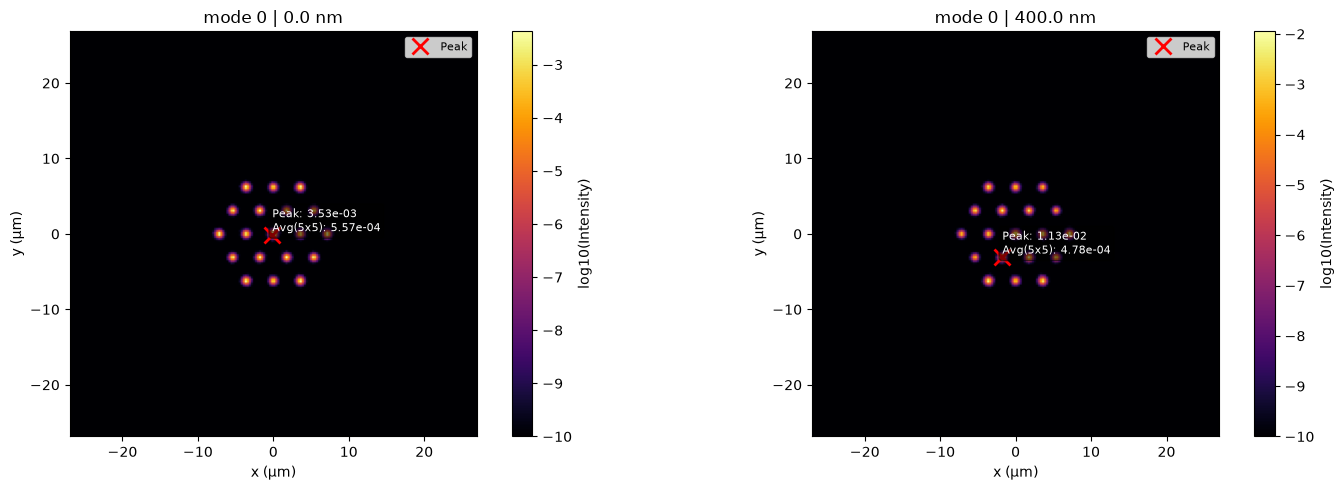

In [13]:
print("Generating visualization...\n")

# labels1 (built alongside coeff1 above) gives a human-readable title per
# ramp step, e.g. "mode 0 | 200.0 nm" -- show the first and last steps.
show_idx = [0, len(uf_2d_batch1) - 1]
titles = [labels1[i] for i in show_idx]

visualize_batch_output(uf_2d_batch1[show_idx], X_plot1, Y_plot1, titles,
                       max_fields=len(show_idx), show_arrow=False)


## Detect output core centres and align to the ideal hex grid

In [14]:
# Sum intensity across the ramp-batch fields so every core lights up at
# least once, then locate the 19 output-core centres on that combined image.
first_intensity = uf_2d_batch0.sum(axis=0)
core_centers = detect_centers_from_grid(first_intensity, X_plot0, Y_plot0)
print(f"Detected {len(core_centers)} core centers")

x_min, y_min = X_plot0[0, 0], Y_plot0[0, 0]
dx = X_plot0[0, 1] - X_plot0[0, 0]
dy = Y_plot0[1, 0] - Y_plot0[0, 0]

ideal_permutation = map_evaluated_to_ideal_geometry(core_centers, ideal_grid_positions)


[peaks] resolved 19 cores at threshold 0.056.
Detected 19 core centers
[Geometric Fit] Detected/ideal scale ratio: 3.606
[Geometric Fit] Residual matching RMS error: 1.0812e-02



## Extract per-core signals and display the hex-grid readout

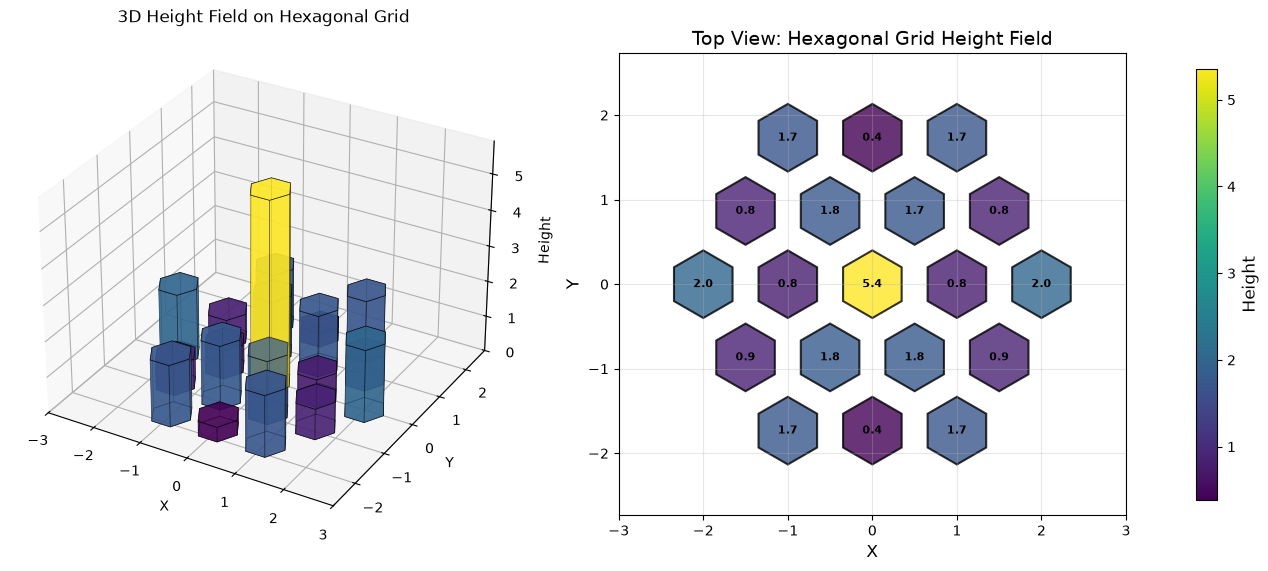

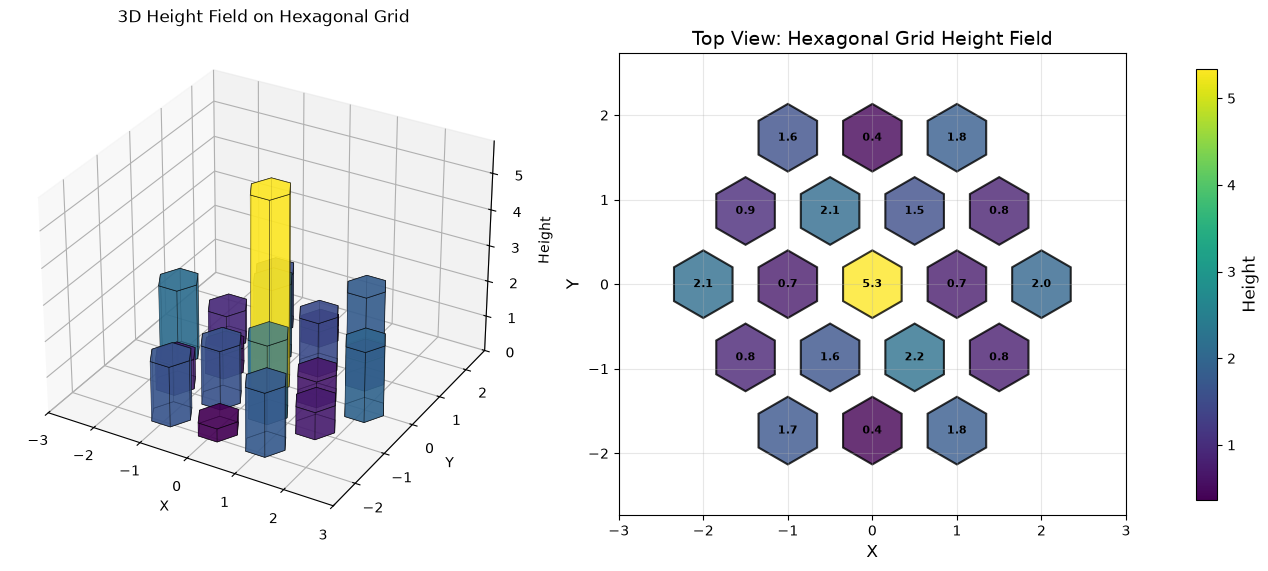

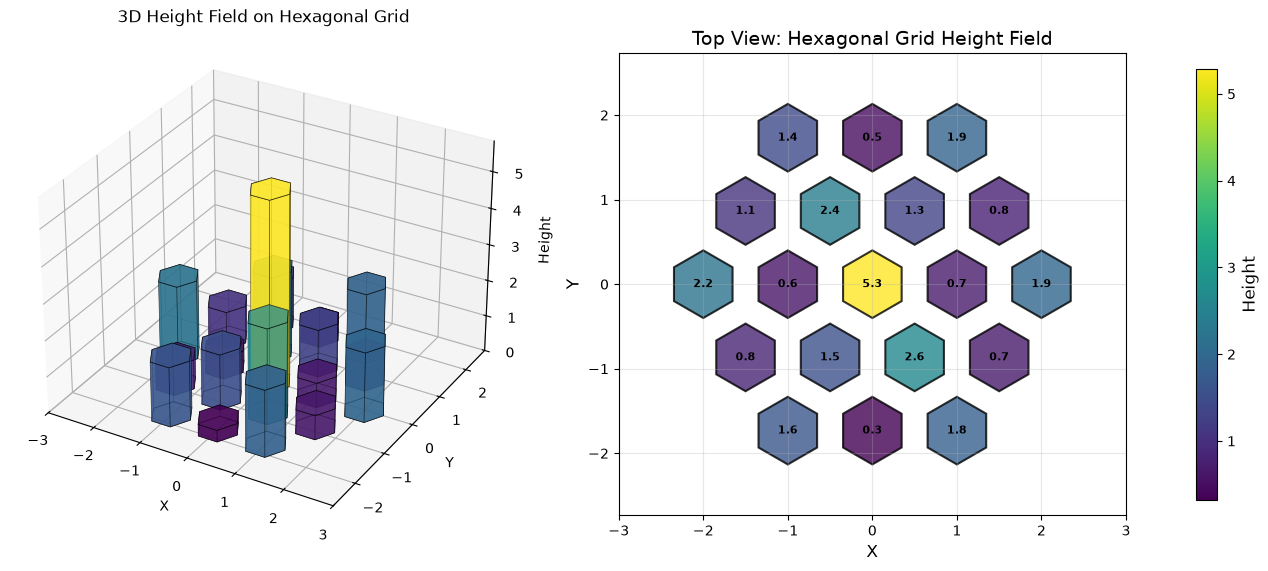

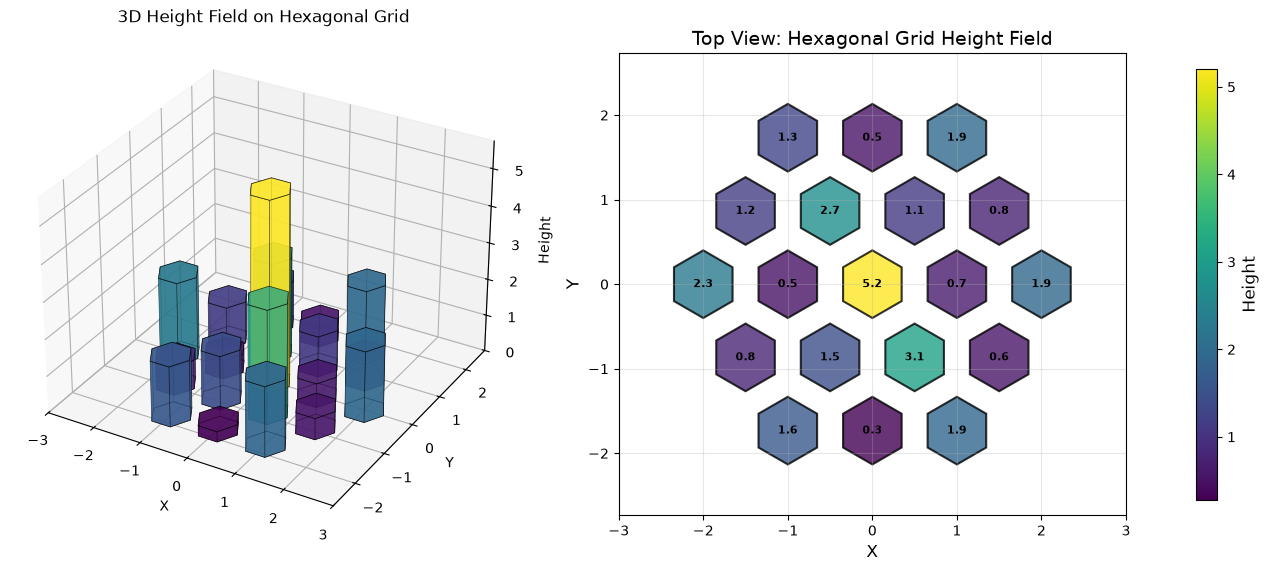

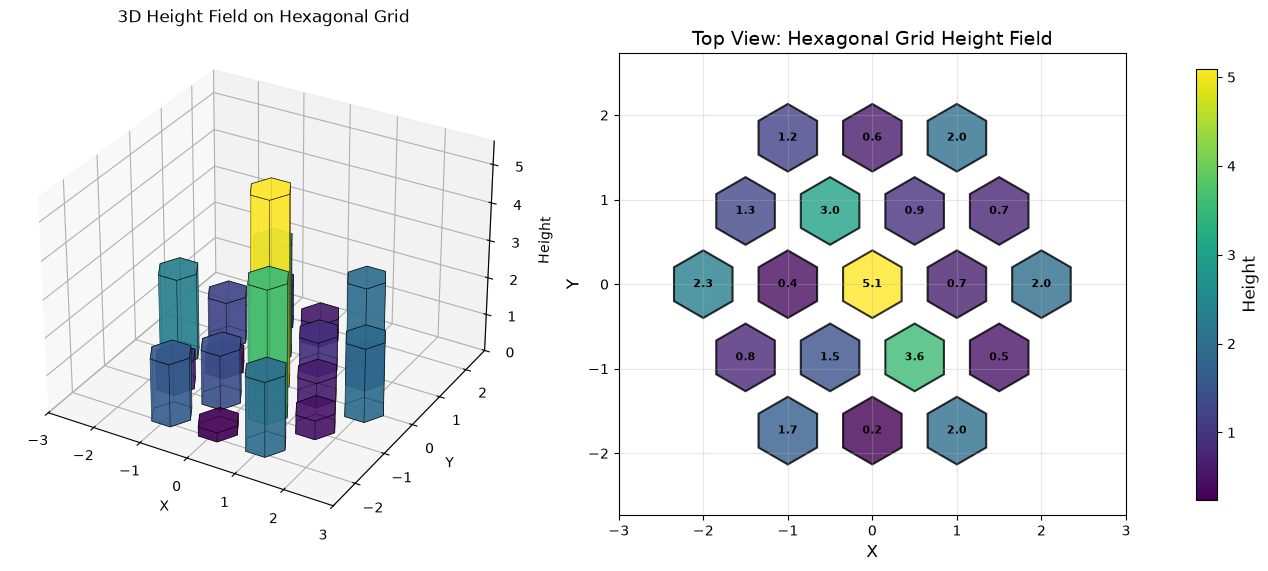

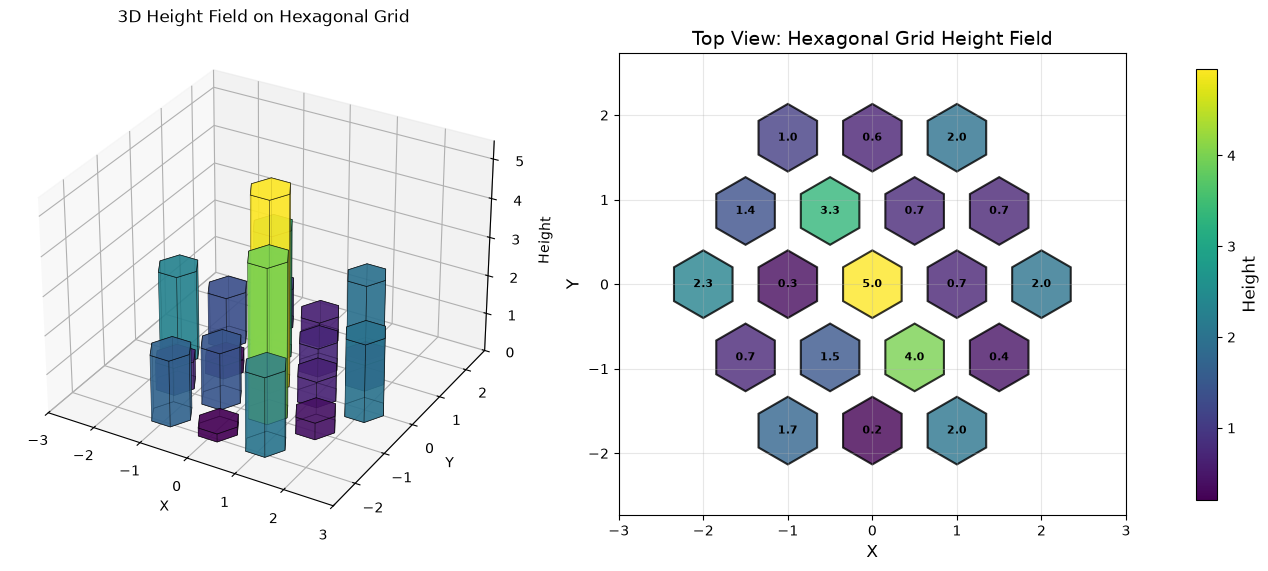

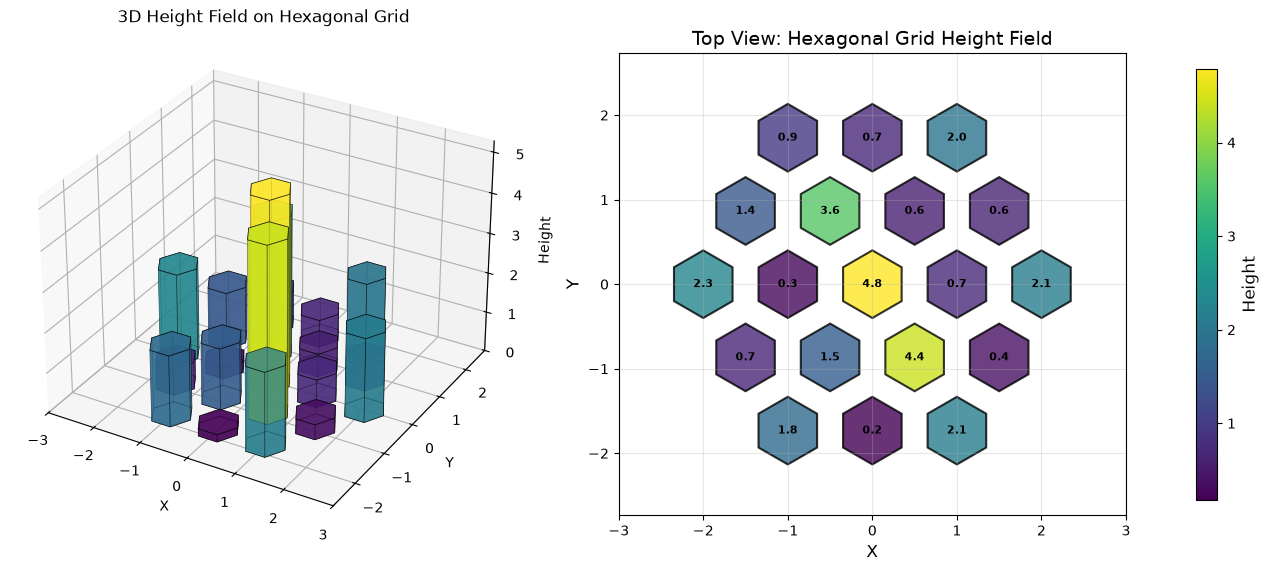

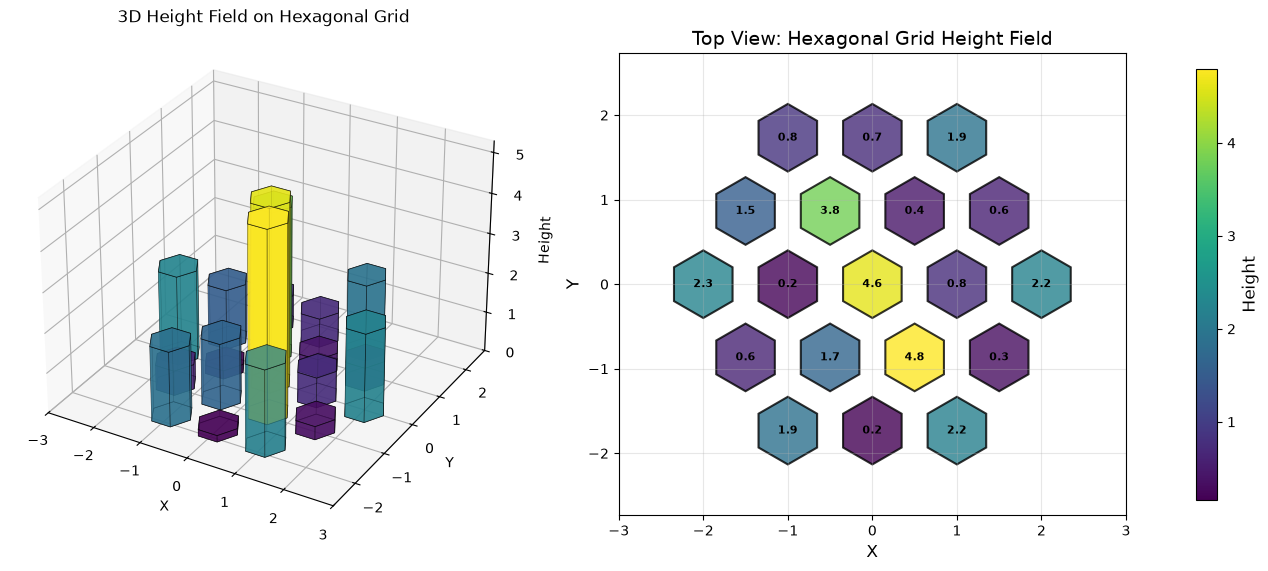

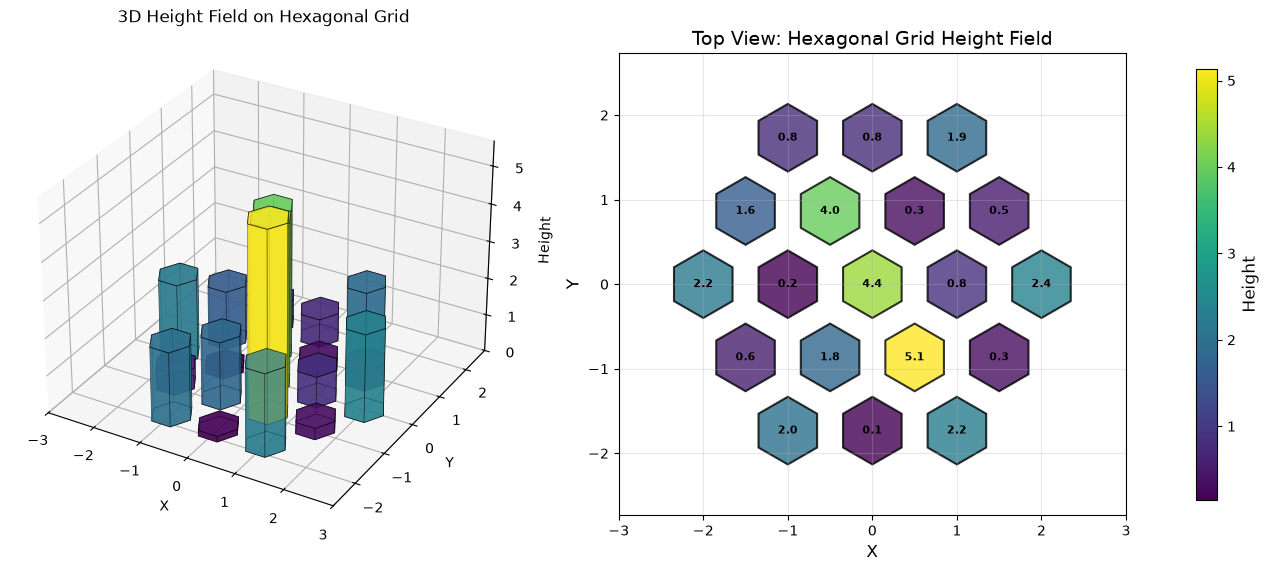

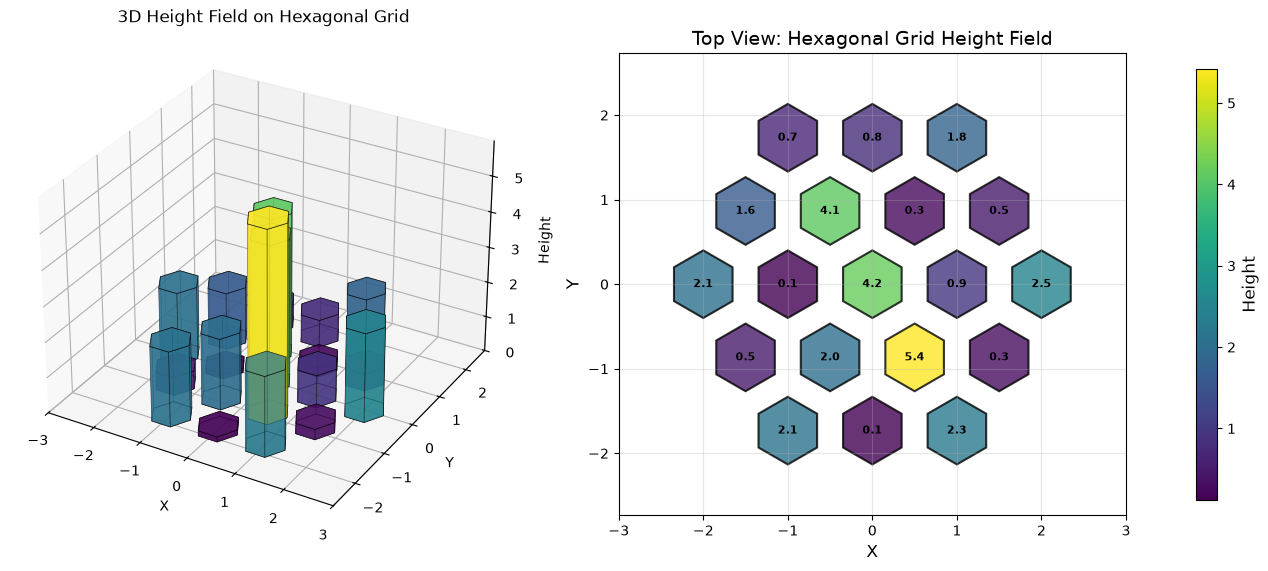

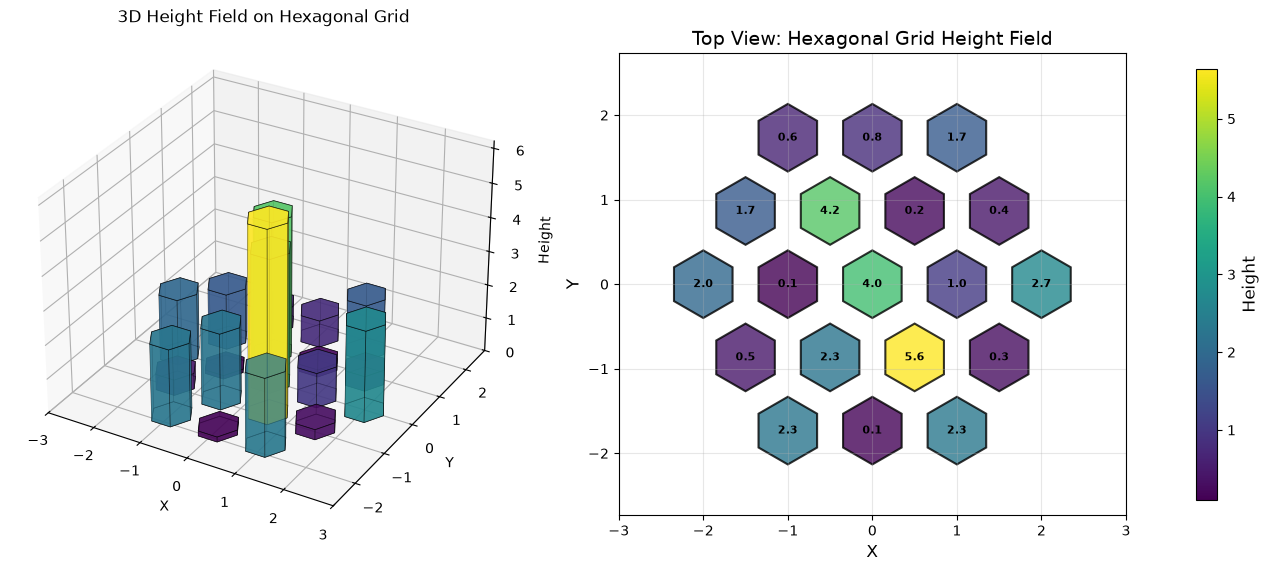

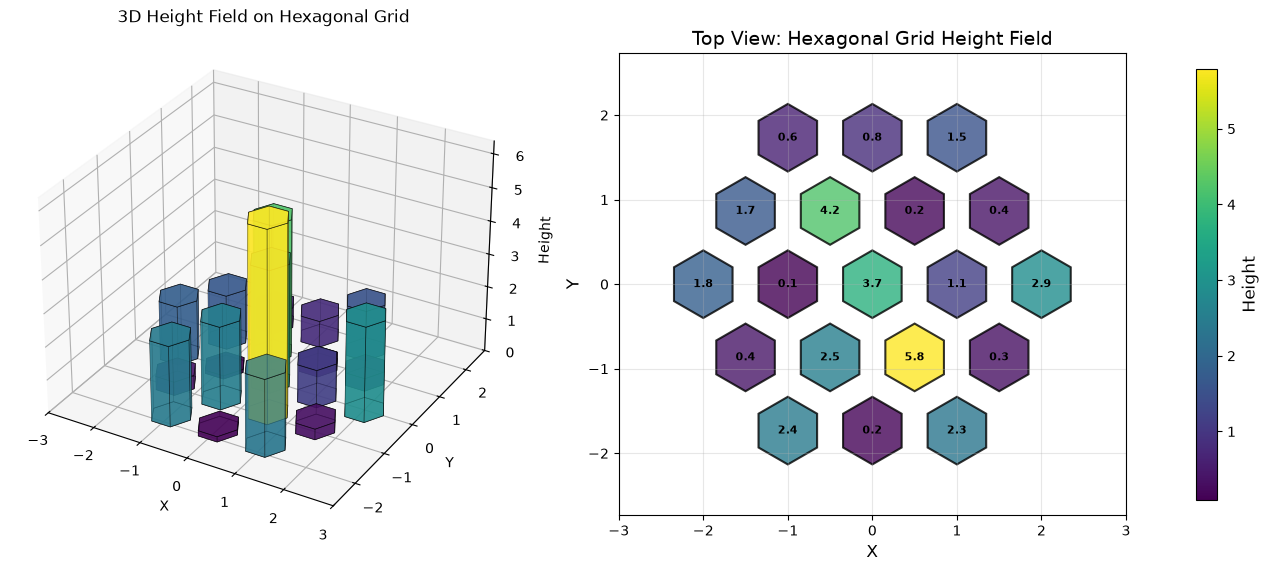

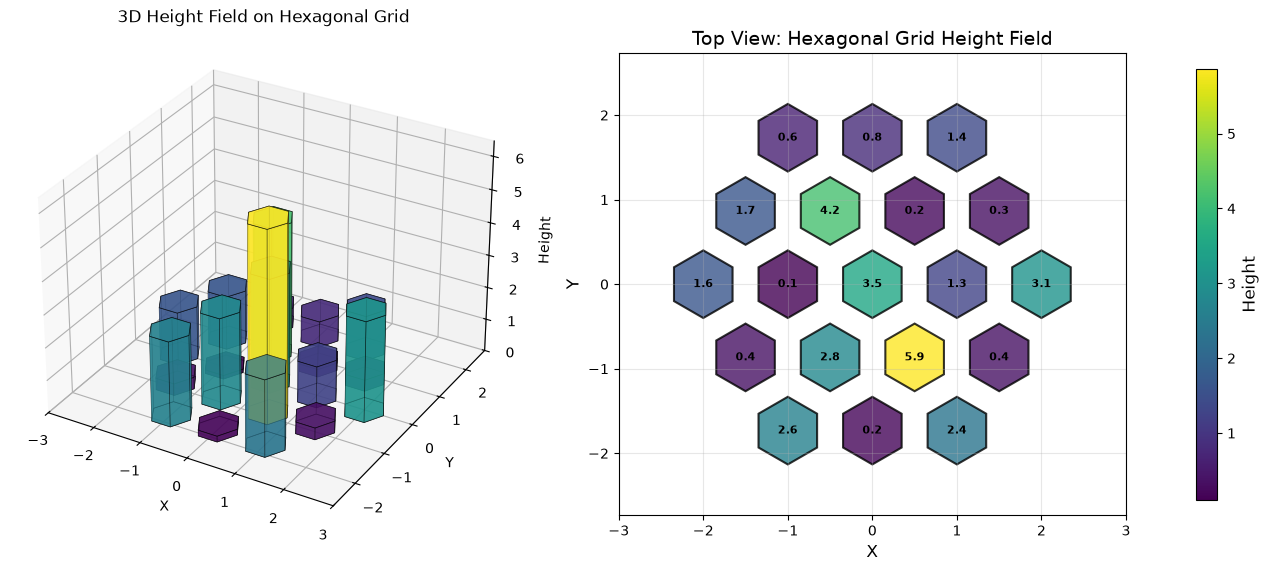

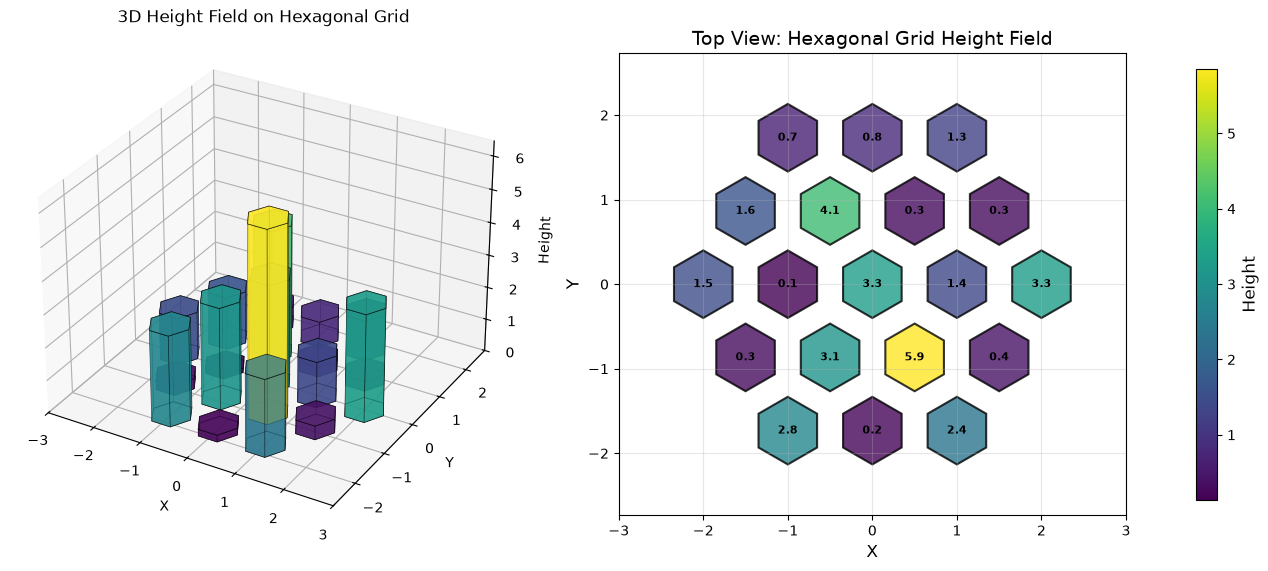

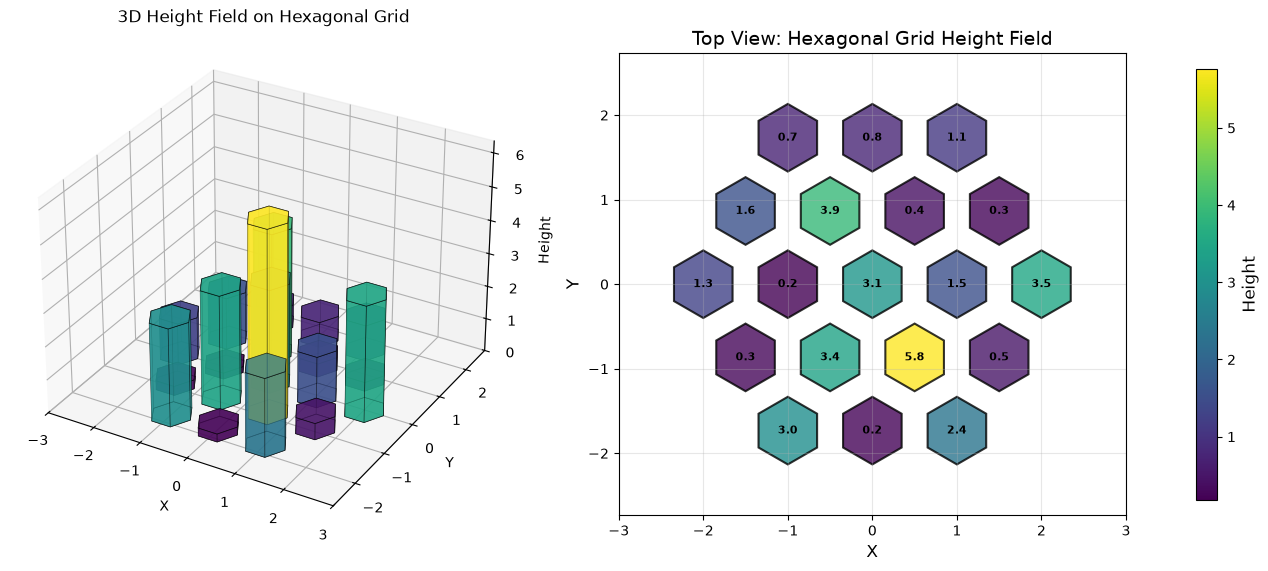

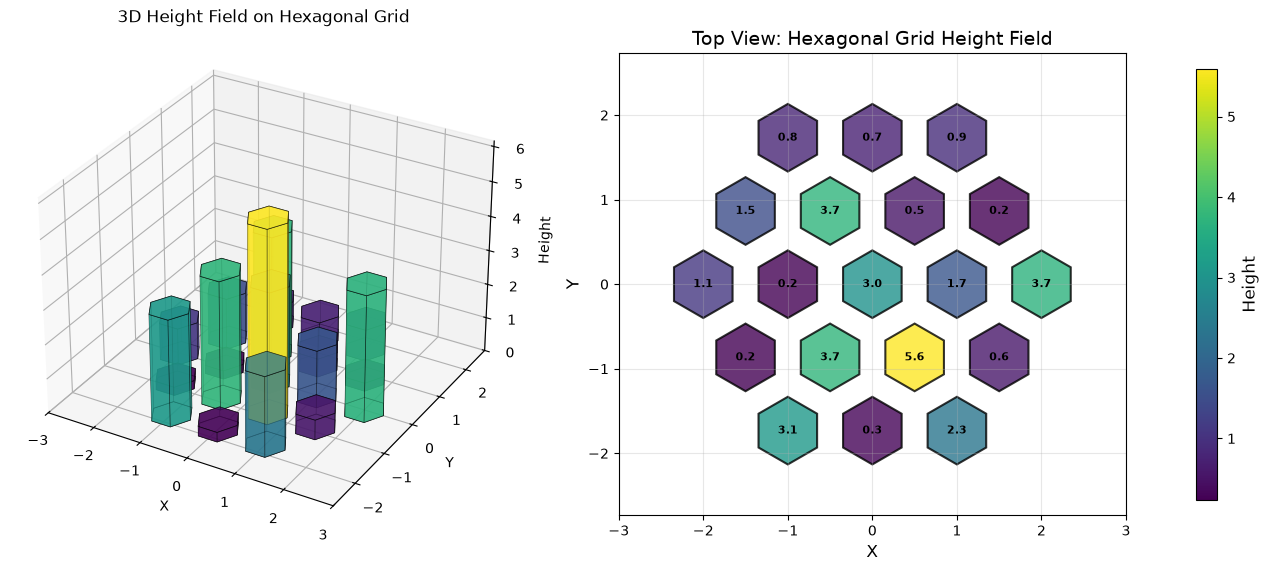

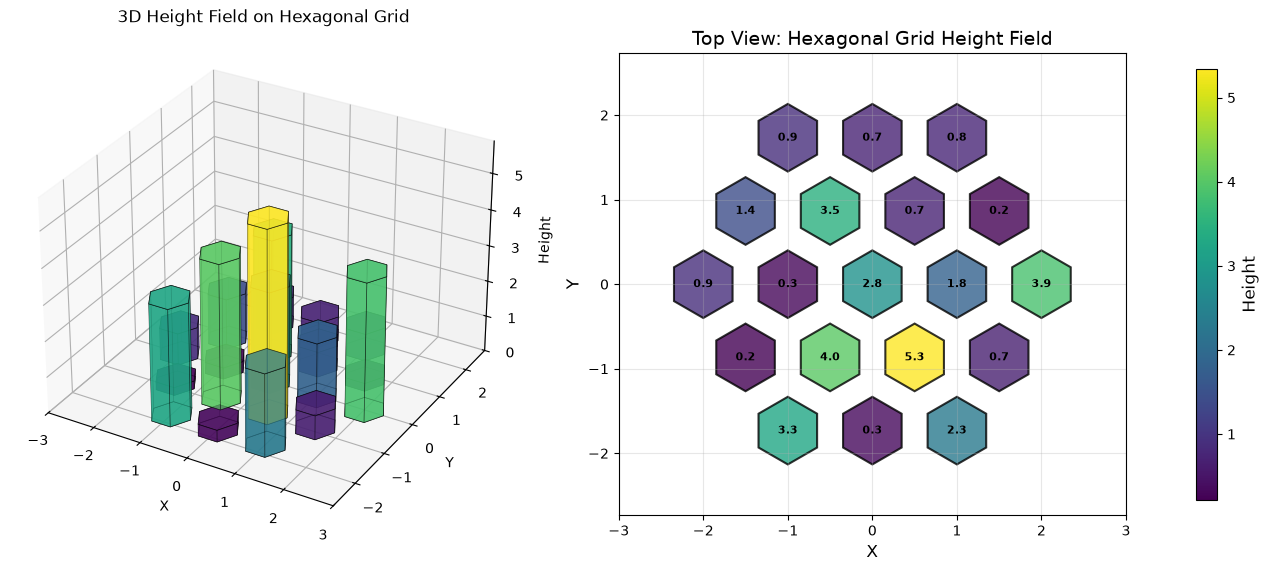

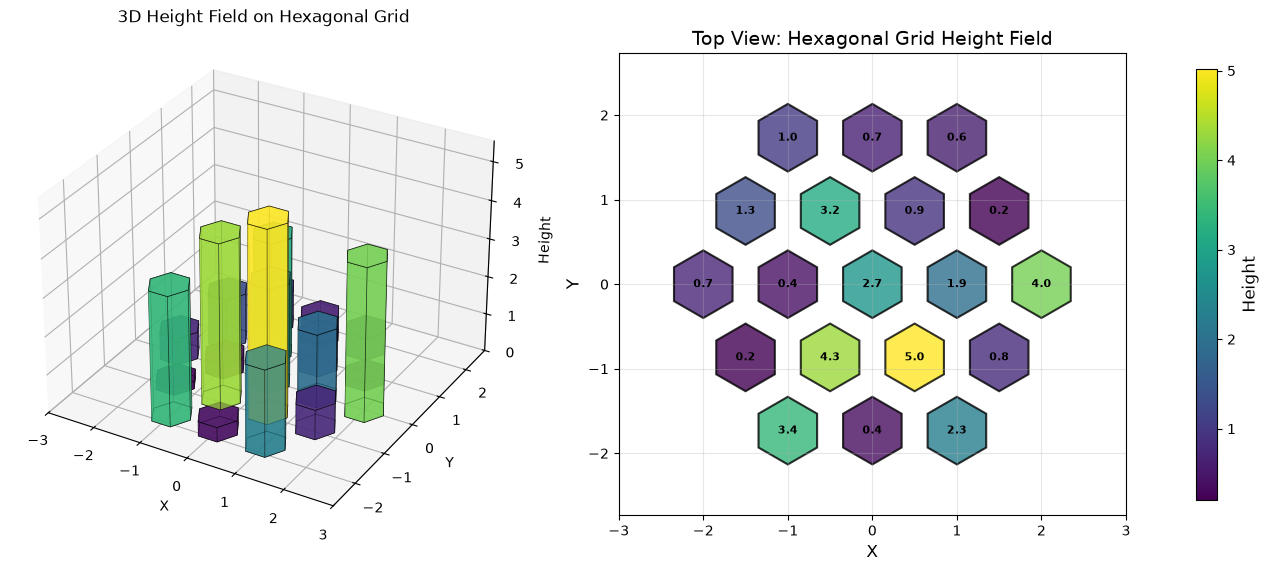

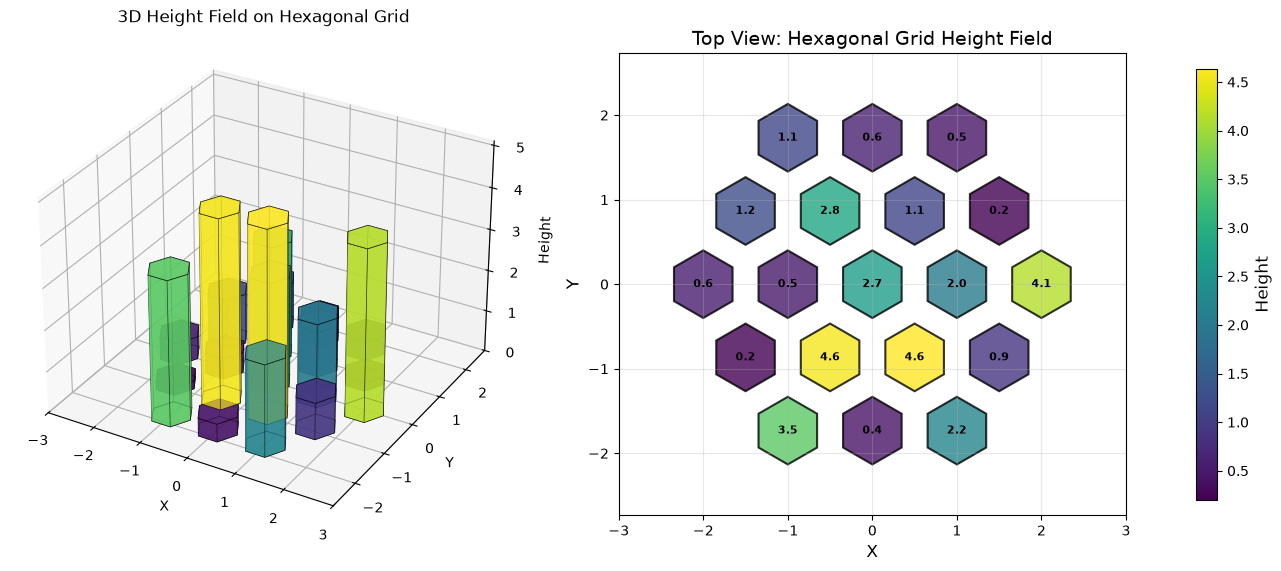

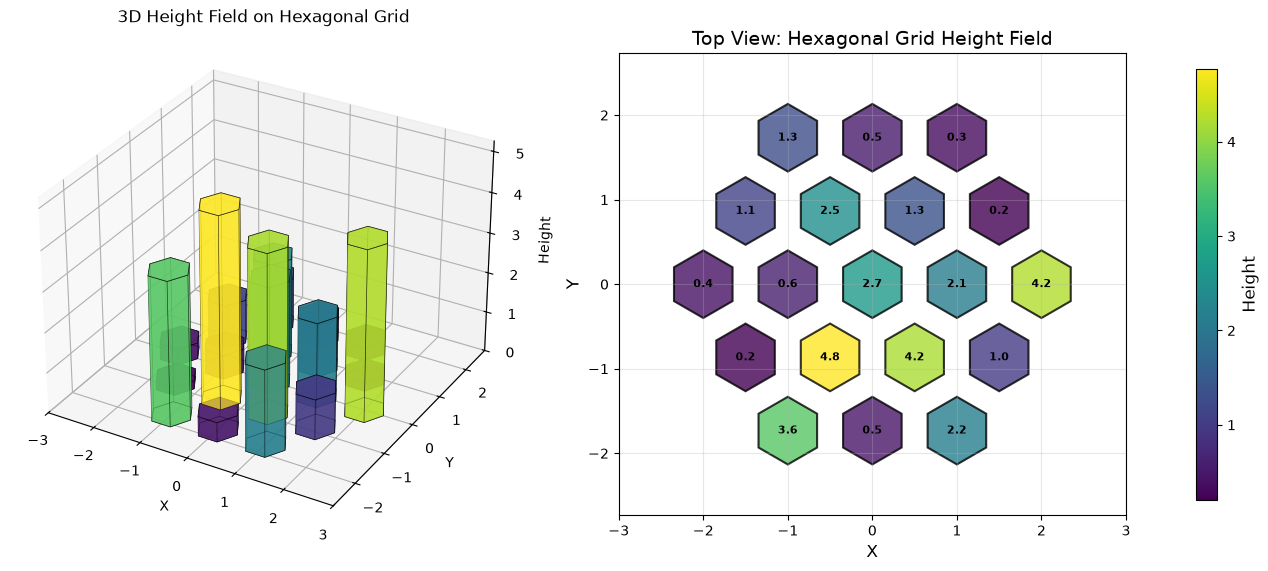

In [15]:
display_scale = 10  # arbitrary visual amplification, for readability in the hex-height plot

for i in range(len(uf_2d_batch1)):
    signals = collect_subpixel_signals(uf_2d_batch1[i], x_min, y_min, dx, dy, core_centers)
    standardized = np.zeros(N_SIGNALS)
    standardized[ideal_permutation] = signals * display_scale
    display_hex_grid_plots(ideal_grid_positions, standardized)


For a specula-free, pure numpy-vs-JAX / batched-vs-one-at-a-time efficiency
comparison of the `propagate()` step used above, see `Batched.ipynb`.